In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('exoplanets_2018.csv')


In [13]:
print(df.head().to_string())

      kepid kepoi_name   kepler_name koi_disposition koi_pdisposition  koi_score  koi_fpflag_nt  koi_fpflag_ss  koi_fpflag_co  koi_fpflag_ec  koi_period  koi_period_err1  koi_period_err2  koi_time0bk  koi_time0bk_err1  koi_time0bk_err2  koi_impact  koi_impact_err1  koi_impact_err2  koi_duration  koi_duration_err1  koi_duration_err2  koi_depth  koi_depth_err1  koi_depth_err2  koi_prad  koi_prad_err1  koi_prad_err2  koi_teq  koi_teq_err1  koi_teq_err2  koi_insol  koi_insol_err1  koi_insol_err2  koi_model_snr  koi_tce_plnt_num koi_tce_delivname  koi_steff  koi_steff_err1  koi_steff_err2  koi_slogg  koi_slogg_err1  koi_slogg_err2  koi_srad  koi_srad_err1  koi_srad_err2         ra        dec  koi_kepmag
0  10797460  K00752.01  Kepler-227 b       CONFIRMED        CANDIDATE      1.000              0              0              0              0    9.488036     2.780000e-05    -2.780000e-05   170.538750          0.002160         -0.002160       0.146            0.318           -0.146       2.95

#remove irrelevant colmuns

In [14]:
data_leak_col = ['koi_pdisposition','koi_score','koi_fpflag_nt','koi_fpflag_ss','koi_fpflag_co','koi_fpflag_ec']
irrelevant_data = ['kepid','kepler_name','koi_period_err2','koi_period_err1','koi_time0bk_err1',
                     'koi_time0bk_err2','koi_impact_err1','koi_impact_err2','koi_tce_delivname','koi_duration_err1','koi_duration_err2',
                     'koi_depth_err1','koi_depth_err2','koi_prad_err1','koi_prad_err2','koi_teq_err1','koi_teq_err2','koi_insol_err1',
                     'koi_insol_err2','koi_steff_err1','koi_steff_err2','koi_slogg_err1','koi_slogg_err2','koi_srad_err1','koi_srad_err2']

In [15]:
cols_to_drop = data_leak_col + irrelevant_data
df = df.drop(columns=cols_to_drop)

In [16]:
# to make a data binary for sure we remove the CANDIATE
df = df[df['koi_disposition'] != 'CANDIDATE']

#EDA

In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4935 entries, 0 to 6325
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kepoi_name        4935 non-null   object 
 1   koi_disposition   4935 non-null   object 
 2   koi_period        4935 non-null   float64
 3   koi_time0bk       4935 non-null   float64
 4   koi_impact        4825 non-null   float64
 5   koi_duration      4935 non-null   float64
 6   koi_depth         4825 non-null   float64
 7   koi_prad          4825 non-null   float64
 8   koi_teq           4825 non-null   float64
 9   koi_insol         4833 non-null   float64
 10  koi_model_snr     4825 non-null   float64
 11  koi_tce_plnt_num  4672 non-null   float64
 12  koi_steff         4825 non-null   float64
 13  koi_slogg         4825 non-null   float64
 14  koi_srad          4825 non-null   float64
 15  ra                4935 non-null   float64
 16  dec               4935 non-null   float64
 17  

In [18]:
print(df.isna().sum())                          # عدد الـ NaN في كل عمود
print(df.isna().sum() / len(df) * 100)          # نسبة الـ NaN المئوية في كل عمود

kepoi_name            0
koi_disposition       0
koi_period            0
koi_time0bk           0
koi_impact          110
koi_duration          0
koi_depth           110
koi_prad            110
koi_teq             110
koi_insol           102
koi_model_snr       110
koi_tce_plnt_num    263
koi_steff           110
koi_slogg           110
koi_srad            110
ra                    0
dec                   0
koi_kepmag            0
dtype: int64
kepoi_name          0.000000
koi_disposition     0.000000
koi_period          0.000000
koi_time0bk         0.000000
koi_impact          2.228977
koi_duration        0.000000
koi_depth           2.228977
koi_prad            2.228977
koi_teq             2.228977
koi_insol           2.066869
koi_model_snr       2.228977
koi_tce_plnt_num    5.329281
koi_steff           2.228977
koi_slogg           2.228977
koi_srad            2.228977
ra                  0.000000
dec                 0.000000
koi_kepmag          0.000000
dtype: float64


In [19]:
df.dropna().shape

(4635, 18)

In [20]:
df = df.dropna()

In [21]:
print(df.isna().sum())

kepoi_name          0
koi_disposition     0
koi_period          0
koi_time0bk         0
koi_impact          0
koi_duration        0
koi_depth           0
koi_prad            0
koi_teq             0
koi_insol           0
koi_model_snr       0
koi_tce_plnt_num    0
koi_steff           0
koi_slogg           0
koi_srad            0
ra                  0
dec                 0
koi_kepmag          0
dtype: int64


In [22]:
#to see if one value is too lagre than the other the model will be bias to it
print(df['koi_disposition'].value_counts())
print(df['koi_disposition'].value_counts(normalize=True) * 100)

koi_disposition
FALSE POSITIVE    2327
CONFIRMED         2308
Name: count, dtype: int64
koi_disposition
FALSE POSITIVE    50.204962
CONFIRMED         49.795038
Name: proportion, dtype: float64


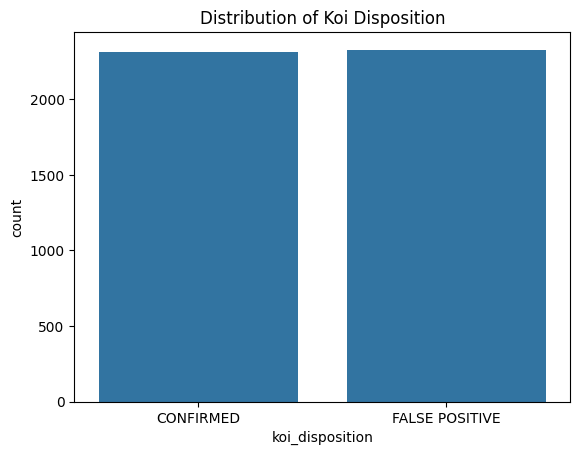

In [23]:
sns.countplot(data=df, x='koi_disposition')
plt.title('Distribution of Koi Disposition')
plt.show()

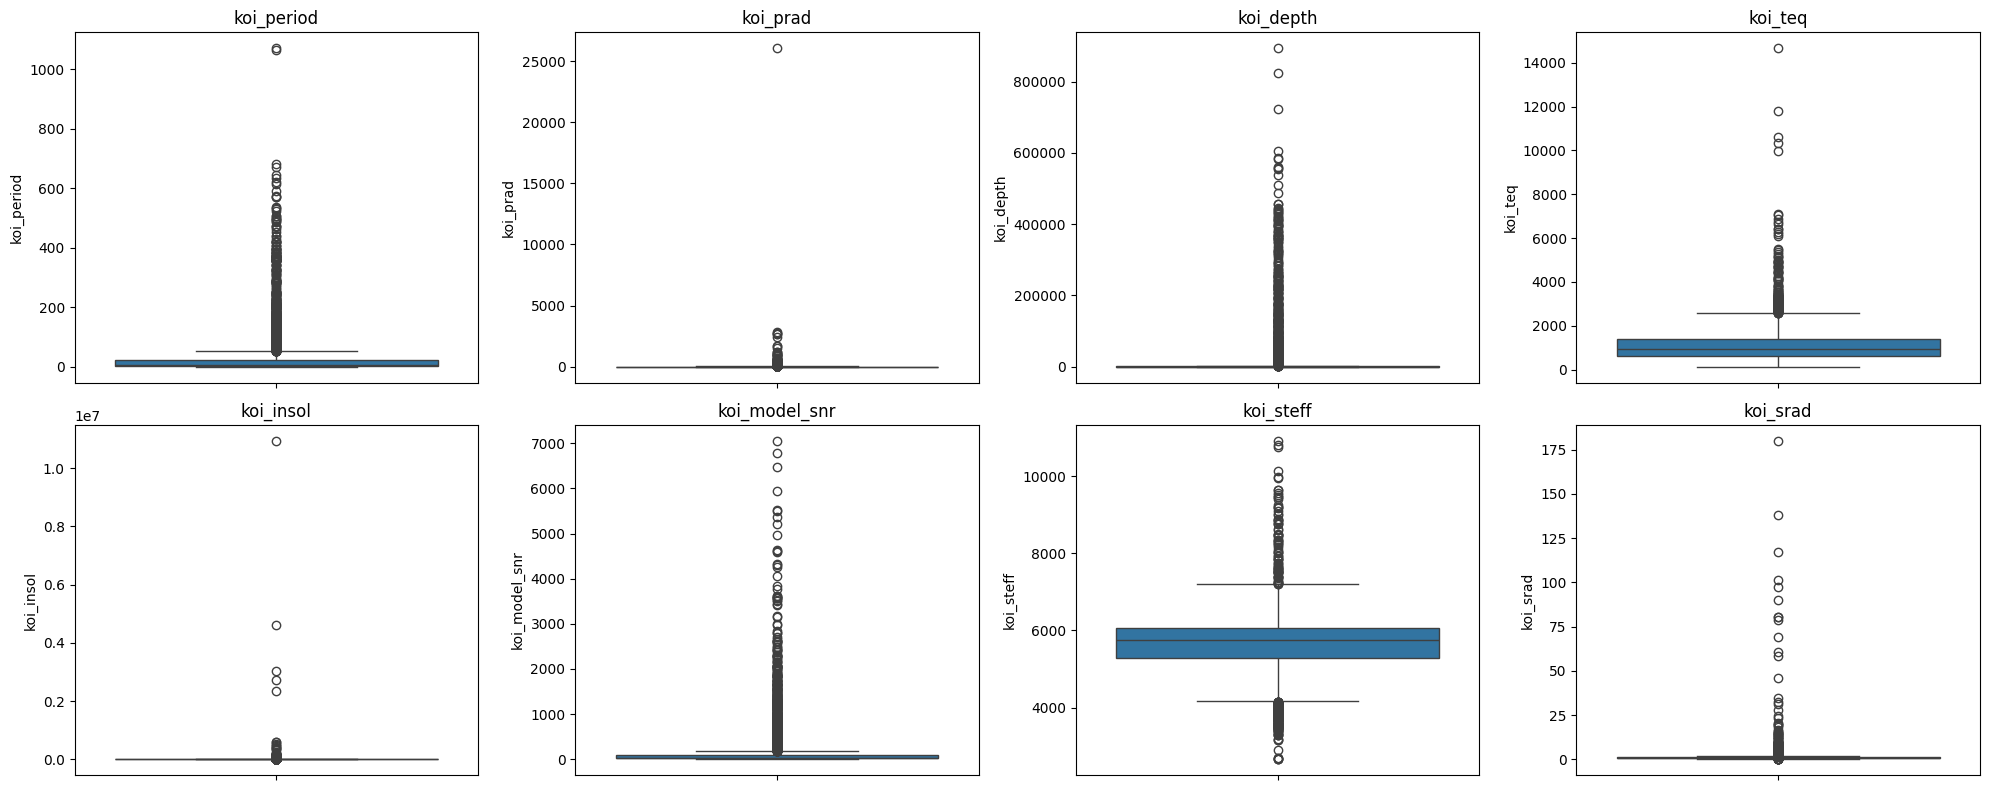

In [24]:
#to see outlier
cols = ['koi_period', 'koi_prad', 'koi_depth', 'koi_teq',
        'koi_insol', 'koi_model_snr', 'koi_steff', 'koi_srad']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [25]:
print(df.shape)

(4635, 18)


In [26]:
# so the is for plant so it is normal that differ and outlier
# but we will do something to make numbers closer to each other (log)

cols_to_log = ['koi_period', 'koi_prad', 'koi_depth', 'koi_insol', 'koi_model_snr','koi_impact','koi_teq','koi_srad','koi_time0bk']

for col in cols_to_log:
    df[col] = np.log1p(df[col])  # log1p = log(1+x) عشان يتعامل مع القيم صفر

In [27]:
print(df.describe())

        koi_period  koi_time0bk   koi_impact  koi_duration    koi_depth  \
count  4635.000000  4635.000000  4635.000000   4635.000000  4635.000000   
mean      2.327986     5.034674     0.439077      4.941740     6.590940   
std       1.365468     0.229104     0.308086      5.548749     2.036562   
min       0.262132     4.800457     0.000000      0.296100     0.587787   
25%       1.229064     4.896416     0.187309      2.369850     5.267858   
50%       2.138911     4.926595     0.466247      3.579100     6.177944   
75%       3.146642     5.143455     0.648150      5.585260     7.208600   
max       6.977498     6.616329     3.636143     90.950000    13.703462   

          koi_prad      koi_teq    koi_insol  koi_model_snr  koi_tce_plnt_num  \
count  4635.000000  4635.000000  4635.000000    4635.000000       4635.000000   
mean      1.793779     6.828556     5.201874       3.892283          1.256958   
std       1.275691     0.610557     2.347176       1.305192          0.654812   


In [28]:
df['target'] = df['koi_disposition'].map({'CONFIRMED': 1, 'FALSE POSITIVE': 0})

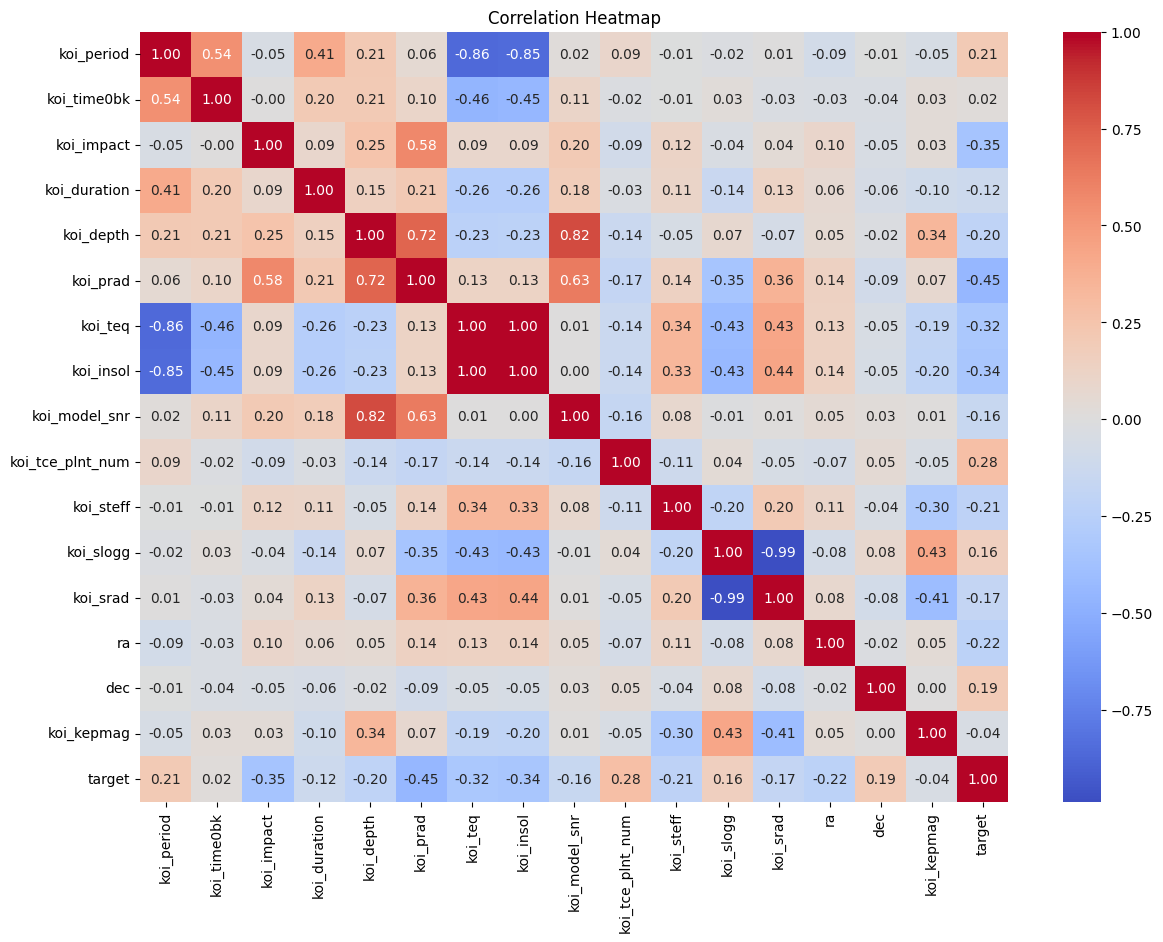

In [29]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [30]:
correlation_with_target = df.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlation_with_target)

target              1.000000
koi_tce_plnt_num    0.282032
koi_period          0.206238
dec                 0.194264
koi_slogg           0.158799
koi_time0bk         0.019584
koi_kepmag         -0.041054
koi_duration       -0.117967
koi_model_snr      -0.155523
koi_srad           -0.172252
koi_depth          -0.203890
koi_steff          -0.214212
ra                 -0.224519
koi_teq            -0.321707
koi_insol          -0.335119
koi_impact         -0.352714
koi_prad           -0.449649
Name: target, dtype: float64


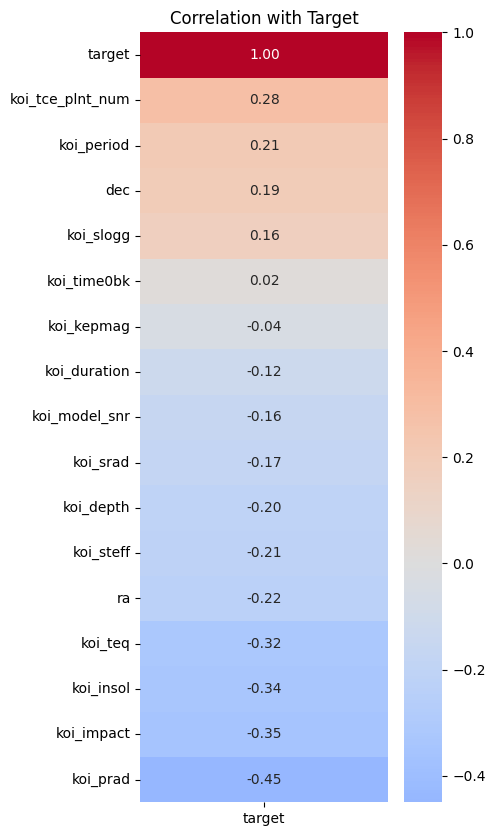

In [31]:
plt.figure(figsize=(4, 10))
sns.heatmap(correlation_with_target.to_frame(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation with Target')
plt.show()

In [32]:
cols = ['koi_kepmag','koi_time0bk','koi_disposition']
df = df.drop(columns=cols)


In [33]:
print(df.head())

  kepoi_name  koi_period  koi_impact  koi_duration  koi_depth  koi_prad  \
0  K00752.01    2.350235    0.136278       2.95750   6.424869  1.181727   
1  K00752.02    4.014911    0.461215       4.50700   6.775366  1.342865   
3  K00754.01    1.006845    0.822420       2.40641   8.997271  3.539799   
4  K00755.01    1.260048    0.531216       1.65450   6.403574  1.321756   
5  K00756.01    2.492736    0.430483       4.59450   7.327123  1.589235   

    koi_teq  koi_insol  koi_model_snr  koi_tce_plnt_num  koi_steff  koi_slogg  \
0  6.677083   4.549552       3.605498               1.0     5455.0      4.467   
1  6.095825   2.313525       3.288402               2.0     5455.0      4.467   
3  7.241366   6.794542       6.227722               1.0     5805.0      4.564   
4  7.249215   6.832126       3.735286               1.0     6031.0      4.438   
5  6.728629   4.751951       4.212128               1.0     6046.0      4.486   

   koi_srad         ra        dec  target  
0  0.655964  291.9

# Modling


In [34]:
# the number of exambles n
n = len(df)
n

4635

train/test split

in the train/test split
1- frist we need an arrage data
2-second we split by 80 for train and 20 for test

In [35]:
# we need a rondom data to  make sure that each sample not a catogry
df = df.sample(frac=1, random_state=42) # frac to take all sample

In [36]:
#we get train size
train_size = int(n * 0.8)

In [37]:
#split
train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [38]:
#we need x_train and y_train split to train the model for
# x_fueatures and y the answer
X_train = train.drop(["target", "kepoi_name"], axis=1)
y_train = train["target"]

In [39]:
# same thing in test data
X_test = test.drop(["target", "kepoi_name"], axis=1)
y_test = test["target"]

In [40]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(3708, 14)
(3708,)
(927, 14)
(927,)


data scling

In [41]:
# for work with data numarically we convert to numby
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [42]:
X_train.shape

(3708, 14)

In [43]:
# scale -> (xi - mui)/segma
# mean(mu)
mu = np.mean(X_train, axis=0)

In [44]:
#segma
segma = np.std(X_train, axis=0)

In [45]:
X_train_scaled = (X_train - mu) / segma

In [46]:
print(X_train_scaled)

[[ 0.9026242   0.62821397 -0.27547569 ... -0.03304783  1.13483219
  -0.21039099]
 [-1.09481999  0.25683863 -0.39915551 ...  0.46193371  1.27561282
  -0.63712782]
 [ 0.07247871  0.41915019 -0.29520883 ... -0.44720398 -0.93741293
   0.18153405]
 ...
 [ 1.06059676  0.24881444 -0.32884914 ... -0.09775742 -0.32085481
  -0.66180307]
 [-0.46661107  0.81653989  2.72546555 ... -0.21754609 -1.60052886
   0.41055551]
 [-1.24508126  1.26060139 -0.62845463 ... -0.33819322  0.47631469
   1.62204854]]


In [47]:
X_test_scaled = (X_test - mu) / segma

logistic regression

In [48]:
# set the model basics

#frist m -> number of training exambles n-> number of faetures
m, n = X_train_scaled.shape
print(f'number of exambles = {m} and number of faetures = {n}')


number of exambles = 3708 and number of faetures = 14


In [49]:
#set w,b initail = 0
w = np.zeros(n)
b = 0

In [50]:
#make the model z = w * x + b
def model(x,w,b):
    z = np.dot(x, w) + b
    return z


In [51]:
#make logistic regrssion (sigmoid)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [52]:
z = model(X_train_scaled, w, b)
f_wb = sigmoid(z)
print(f_wb)

[0.5 0.5 0.5 ... 0.5 0.5 0.5]


cost function

In [53]:
#compute cost
def compute_cost(f_wb, y):
    cost = -(1/m) * np.sum(
        y * np.log(f_wb) +
        (1-y) * np.log(1-f_wb)
    )

    return cost

In [54]:
cost = compute_cost(f_wb, y_train)
print(cost)

0.6931471805599452


grediend descent

In [55]:
#grediend descent that we see every time how far we are and reach the depth point
#so w = w - alpha * djdw
#   b = b - alpha * djdb
#frist inital the learning rate alpha with initail value
alphe = 2


In [56]:
#then compute_gradient dj_dw , dj_db
def compute_gradient(x, y, f_wb):
    dj_dw = (1/m) * np.dot(x.T, (f_wb - y))
    dj_db = (1/m) * np.sum(f_wb - y)

    return dj_dw, dj_db

In [57]:
#then gradient descent
cost_history = []
w_history = []
b_history = []
def gradient_descent(x, y, w, b, alphe, num_iters):

    for i in range(num_iters+1):
        z = np.dot(x, w) + b
        f_wb = sigmoid(z)

        dj_dw, dj_db = compute_gradient(x, y, f_wb)
        w = w - alphe * dj_dw
        b = b - alphe * dj_db



        cost = compute_cost(f_wb, y)

        if i % 100 == 0:
            print(f'Iteration {i}: Cost {cost}')

        cost_history.append(cost)
        w_history.append(w)
        b_history.append(b)

In [58]:
gradient_descent(X_train_scaled, y_train, w, b, alphe, 600)

Iteration 0: Cost 0.6931471805599452
Iteration 100: Cost 0.37306023273162986
Iteration 200: Cost 0.36032487078473024
Iteration 300: Cost 0.3530974905394462
Iteration 400: Cost 0.3485758009647996
Iteration 500: Cost 0.34559957887489007
Iteration 600: Cost 0.343565742184146


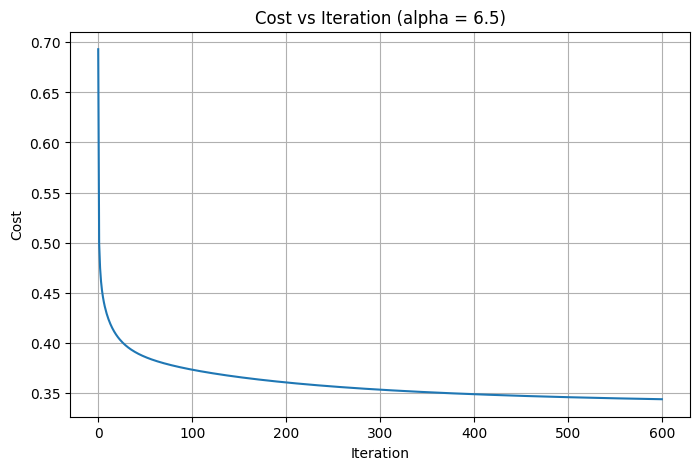

In [59]:
plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration (alpha = 6.5)')
plt.grid(True)
plt.show()

In [60]:
# there is two important things
# one if the learning rate alpha is big we might be in rask if we skipt the smallest cost
# and if we chinge the data it might not fit
# two if alpha is small we will need more iterition and it waste the cpu

#linear regression (prediction)

🌍 Can we predict a planet's equilibrium temperature from its observed properties?

In [61]:
# train/test split
train_r = df.iloc[:train_size]
test_r = df.iloc[train_size:]

In [62]:
x_train_r = train_r.drop(['koi_teq','target','koi_insol',"kepoi_name"], axis=1)
y_train_r = train_r['koi_teq']

x_test_r = test_r.drop(['koi_teq','target','koi_insol',"kepoi_name"], axis=1)
y_test_r = test_r['koi_teq']

In [63]:
feature_names_r = x_train_r.columns.tolist()
print(feature_names_r)

['koi_period', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_steff', 'koi_slogg', 'koi_srad', 'ra', 'dec']


In [64]:
x_train_r = x_train_r.to_numpy()
x_test_r = x_test_r.to_numpy()

y_train_r = y_train_r.to_numpy()
y_test_r = y_test_r.to_numpy()

In [65]:
# mu for the x train regression
mu_r = np.mean(x_train_r, axis=0)

In [66]:
# std for the x train regression
segma_r = np.std(x_train_r, axis=0)

In [67]:
# scale
x_train_r_scaled = (x_train_r - mu_r) / segma_r
x_test_r_scaled = (x_test_r - mu_r) / segma_r



In [68]:
#mu_r_y
mu_r_y = np.mean(y_train_r, axis=0)

#std_r_y
segma_r_y = np.std(y_train_r, axis=0)

#scale
y_train_r_scaled = (y_train_r - mu_r_y) / segma_r_y
y_test_r_scaled = (y_test_r - mu_r_y) / segma_r_y

In [69]:
print(np.std(x_train_r, axis=0))

[1.36984251e+00 2.98141657e-01 5.32099722e+00 2.02333205e+00
 1.25994454e+00 1.29439111e+00 6.68292626e-01 7.45620038e+02
 3.75948903e-01 3.54762396e-01 4.77771665e+00 3.62865563e+00]


In [70]:
print(np.isnan(x_train_r_scaled).any(), np.isinf(x_train_r_scaled).any())
print(np.isnan(y_train_r_scaled).any(), np.isinf(y_train_r_scaled).any())

False False
False False


In [71]:
#number of examples and feature
m_r ,n_r = x_train_r_scaled.shape
print(f'number of exambles = {m_r} and number of faetures = {n_r}')

number of exambles = 3708 and number of faetures = 12


In [72]:
#linear regression
w_r = np.zeros(n_r)
b_r = 0

In [73]:
#linear regression funcation
def linear_regression(x, w, b):
    f_wb_r = np.dot(x, w) + b
    return f_wb_r

In [74]:
# cost function
l=4
def cost_r(f_wb_r,y_train_r,w_r, lambda_):
    m = len(y_train_r)
    cost = np.sum((f_wb_r - y_train_r) ** 2) / (2 * m)
    reg_cost = (lambda_ / (2 * m)) * np.sum(w_r ** 2)
    return cost + reg_cost

In [75]:
test = linear_regression(x_train_r_scaled, w_r, b_r)
cost_test = cost_r(test, y_train_r_scaled,w_r,l)
print(cost_test)

0.49999999999999994


In [76]:
#gredient descent djdw djdb
def compute_gradient_r(x, y, f_wb_r, w_, lambda_):
    m = len(y)
    dj_dw_r = (1/m) * np.dot(x.T, (f_wb_r - y))+ (lambda_/m) * w_
    dj_db_r = (1/m) * np.sum(f_wb_r - y)

    return dj_dw_r, dj_db_r



In [77]:
#gredient descent function
cost_history_r = []
w_history_r = []
b_history_r = []
alpha_r =.4


def gradient_descent_r(x_, y_, w_, b_, alphe_, num_iters_,l):

    for i in range(num_iters_+1):
        f_wb_r = linear_regression(x_, w_, b_)


        dj_dw_r, dj_db_r = compute_gradient_r(x_ ,y_, f_wb_r,w_,l)
        w_ = w_ - alphe_ * dj_dw_r
        b_ = b_ - alphe_ * dj_db_r



        cost__r = cost_r(f_wb_r,y_ ,w_,l)

        if i % 100 == 0:

            print(f'Iteration {i}: Cost {cost__r}')

        cost_history_r.append(cost__r)
        w_history_r.append(w_)
        b_history_r.append(b_)

    return w_, b_


In [78]:
w_r, b_r = gradient_descent_r(x_train_r_scaled, y_train_r_scaled, w_r, b_r, alpha_r, 200,l)

Iteration 0: Cost 0.5001216164632942
Iteration 100: Cost 0.00573975538042843
Iteration 200: Cost 0.005604911445225931


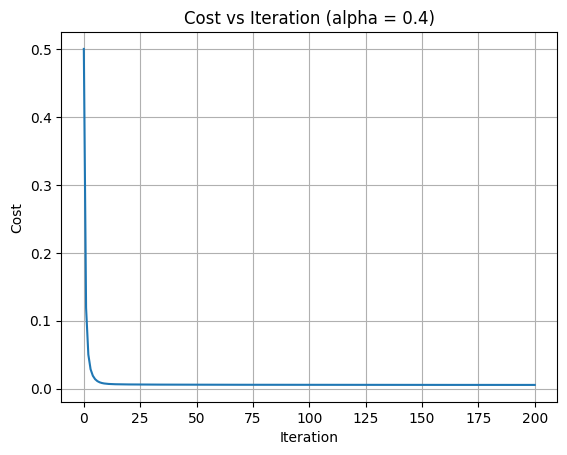

In [79]:
plt.plot(cost_history_r)
plt.xlabel('Iteration')
plt.ylabel('Cost')

plt.title('Cost vs Iteration (alpha = 0.4)')
plt.grid(True)
plt.show()

In [80]:
# to make sure that not an over fitting

f_wb_test = linear_regression(x_test_r_scaled, w_r, b_r)
test_cost = cost_r(f_wb_test, y_test_r_scaled,w_r,4)
print("Test cost:", test_cost)

Test cost: 0.007281366093147342


In [81]:
# there is over fitting the cost frist output is .12 and it s far so we need to pansh w Regularization

In [82]:
print(w_r)

[-8.59815128e-01 -1.09070213e-02  1.69146704e-03 -3.48218875e-02
  3.31863466e-02  6.22744660e-03 -9.58074746e-03  2.46613972e-01
 -3.14732862e-01  4.74616827e-02 -1.59234215e-04 -5.38261782e-03]


In [83]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2) # نسبه الخطا في الموديل
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) # نسبه الخطا في الموديل السادج ال بيقول كل حاجه تساوي المتوسط
    return 1 - (ss_res / ss_tot) # النسبه بين الموديل بتاعنا والموديل السادج

print("R² on test:", r2_score(y_test_r_scaled, f_wb_test))

R² on test: 0.9895966691280316


In [84]:
for name, weight in zip(feature_names_r, w_r):
    print(f"{name}: {weight:.4f}")

koi_period: -0.8598
koi_impact: -0.0109
koi_duration: 0.0017
koi_depth: -0.0348
koi_prad: 0.0332
koi_model_snr: 0.0062
koi_tce_plnt_num: -0.0096
koi_steff: 0.2466
koi_slogg: -0.3147
koi_srad: 0.0475
ra: -0.0002
dec: -0.0054
